# Temas Tratados en el Trabajo Práctico 3

* Estrategias de búsqueda local.

* Algoritmos Evolutivos.

* Problemas de Satisfacción de Restricciones.

# Ejercicios Teóricos

1. ¿Qué mecanismo de detención presenta el algoritmo de Ascensión de Colinas? Describa el problema que puede presentar este mecanismo y cómo se llaman las áreas donde ocurren estos problemas.

## 1. Mecanismo de detención de Ascensión de Colinas

El algoritmo de **Ascensión de Colinas** comienza en un estado inicial y, en cada iteración, evalúa sus estados vecinos. Luego se desplaza hacia el vecino que tenga el mejor valor.

Su mecanismo de detención consiste en finalizar cuando **ningún vecino mejora al estado actual**. Es decir, para un problema de maximización, se detiene cuando:

$$
f(s') \leq f(s)
$$

para todo estado vecino $s'$ del estado actual $s$.

El problema es que esta condición solamente considera la región cercana al estado actual. Por lo tanto, el algoritmo puede detenerse aunque todavía exista una solución mejor en otra región del espacio de búsqueda.

Las principales situaciones problemáticas son:

### Máximo local

Es un estado mejor que todos sus vecinos, pero que no corresponde al máximo global del problema. El algoritmo se detiene porque no encuentra una mejora inmediata.

### Meseta

Es una región donde varios estados vecinos tienen el mismo valor:

$$
f(s_1)=f(s_2)=\cdots=f(s_n)
$$

Como no existe una dirección de mejora clara, el algoritmo puede detenerse o desplazarse sin saber hacia dónde avanzar.

### Cresta

Es una región en la que la dirección de crecimiento no coincide directamente con los movimientos permitidos entre estados. Para continuar mejorando sería necesario realizar una combinación de movimientos, pero el algoritmo solamente analiza movimientos individuales.

Por estas razones, la Ascensión de Colinas no garantiza encontrar el máximo global. Algunas posibles mejoras son utilizar reinicios aleatorios, permitir movimientos laterales durante una cantidad limitada de iteraciones o aplicar métodos como el Recocido Simulado.


2. Describa las distintas heurísticas que se emplean en un problema de Satisfacción de Restricciones.

## 2. Heurísticas empleadas en un Problema de Satisfacción de Restricciones

En un Problema de Satisfacción de Restricciones se deben tomar dos decisiones:

1. Qué variable asignar primero.
2. Qué valor probar primero para esa variable.

Las principales heurísticas utilizadas son las siguientes.

### Variable más restringida o MRV

La heurística MRV, del inglés *Minimum Remaining Values*, selecciona la variable no asignada que tenga la menor cantidad de valores legales disponibles en su dominio.

Si:

$$
D(X)=\{1\}
$$

y:

$$
D(Y)=\{1,2,3\}
$$

se selecciona primero $X$, porque solamente tiene una opción posible.

Esta estrategia también se conoce como principio de **fallar primero**, ya que permite detectar rápidamente si una variable se quedó sin valores posibles.

### Heurística de grado

La heurística de grado selecciona la variable no asignada que tenga la mayor cantidad de restricciones con otras variables que todavía no fueron asignadas.

En la representación mediante un grafo, se elige el nodo que tenga la mayor cantidad de vecinos todavía no asignados.

La idea es asignar primero la variable que más condiciona a las demás. Generalmente se utiliza para desempatar cuando varias variables tienen la misma cantidad de valores disponibles según MRV.

### Valor menos restrictivo

Una vez seleccionada la variable, esta heurística determina qué valor probar primero.

Se elige el valor que elimine la menor cantidad de opciones de los dominios de las variables vecinas.

Por ejemplo, si asignar un valor $a$ elimina dos opciones de los vecinos y asignar un valor $b$ elimina cinco, se prueba primero $a$.

De esta manera se conserva la mayor cantidad posible de alternativas para completar las asignaciones restantes.

### Orden habitual de aplicación

Las heurísticas pueden combinarse de la siguiente manera:

1. Se aplica MRV para seleccionar la variable con menos valores disponibles.
2. Si existe un empate, se aplica la heurística de grado.
3. Para la variable seleccionada, se prueba primero el valor menos restrictivo.

La Comprobación hacia Adelante no es una heurística de selección, sino una técnica de propagación. Después de realizar una asignación, elimina ese valor de los dominios de las variables vecinas y permite detectar anticipadamente si algún dominio queda vacío.

3. Se desea colorear el rompecabezas mostrado en la imagen con 7 colores distintos de manera que ninguna pieza tenga el mismo color que sus vecinas. Realice en una tabla el proceso de una búsqueda con Comprobación hacia Adelante empleando una heurística del Valor más Restringido.

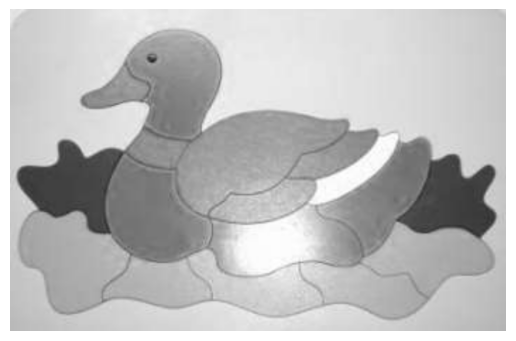

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1j94jFVxVG9y_ZnrMWOscQGb2MZ0Cdb3R"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

## 3. Coloreo del rompecabezas mediante Comprobación hacia Adelante

El problema se representa como un **Problema de Satisfacción de Restricciones (PSR)**.

Cada pieza del rompecabezas es una variable. De acuerdo con la numeración mostrada en la imagen, el rompecabezas contiene 17 piezas:

$$
X=\{P_1,P_2,\ldots,P_{17}\}
$$

El dominio inicial de cada variable contiene los siete colores disponibles:

$$
D(P_i)=\{Ro,Ve,Az,Am,Na,Vi,Ce\}
$$

donde:

- $Ro$: rojo.
- $Ve$: verde.
- $Az$: azul.
- $Am$: amarillo.
- $Na$: naranja.
- $Vi$: violeta.
- $Ce$: celeste.

Dos piezas se consideran vecinas cuando comparten un segmento de borde. Si solamente se tocan en un punto, no se consideran vecinas.

La restricción entre dos piezas vecinas es:

$$
P_i\neq P_j
$$

Esto significa que dos piezas vecinas no pueden recibir el mismo color.

### Identificación de las piezas

| Pieza | Ubicación |
|---|---|
| $P_1$ | Pico |
| $P_2$ | Cabeza y parte superior del cuello |
| $P_3$ | Franja intermedia del cuello |
| $P_4$ | Pecho |
| $P_5$ | Ala superior grande |
| $P_6$ | Parte inferior del ala |
| $P_7$ | Pluma superior de la cola |
| $P_8$ | Franja blanca de la cola |
| $P_9$ | Parte posterior del cuerpo |
| $P_{10}$ | Parte central inferior del cuerpo |
| $P_{11}$ | Pieza oscura del fondo izquierdo |
| $P_{12}$ | Pieza inferior izquierda del fondo |
| $P_{13}$ | Pieza inferior ubicada debajo del pecho |
| $P_{14}$ | Pieza inferior izquierda ubicada debajo del cuerpo |
| $P_{15}$ | Pieza inferior derecha ubicada debajo del cuerpo |
| $P_{16}$ | Pieza inferior derecha del fondo |
| $P_{17}$ | Pieza oscura del fondo derecho |

### Definición de los vecinos

La relación de vecindad es simétrica. Por ejemplo, si $P_1$ es vecina de $P_2$, entonces $P_2$ también debe ser vecina de $P_1$.

| Pieza | Vecinos |
|---|---|
| $P_1$ | $\{P_2\}$ |
| $P_2$ | $\{P_1,P_3,P_5\}$ |
| $P_3$ | $\{P_2,P_4,P_5\}$ |
| $P_4$ | $\{P_3,P_5,P_{10},P_{11},P_{12},P_{13},P_{14}\}$ |
| $P_5$ | $\{P_2,P_3,P_4,P_6,P_7\}$ |
| $P_6$ | $\{P_5,P_7,P_8,P_{10}\}$ |
| $P_7$ | $\{P_5,P_6,P_8\}$ |
| $P_8$ | $\{P_6,P_7,P_9,P_{10}\}$ |
| $P_9$ | $\{P_8,P_{10},P_{16},P_{17}\}$ |
| $P_{10}$ | $\{P_4,P_6,P_8,P_9,P_{14},P_{15},P_{16}\}$ |
| $P_{11}$ | $\{P_4,P_{12}\}$ |
| $P_{12}$ | $\{P_4,P_{11},P_{13}\}$ |
| $P_{13}$ | $\{P_4,P_{12},P_{14}\}$ |
| $P_{14}$ | $\{P_4,P_{10},P_{13},P_{15}\}$ |
| $P_{15}$ | $\{P_{10},P_{14},P_{16}\}$ |
| $P_{16}$ | $\{P_9,P_{10},P_{15},P_{17}\}$ |
| $P_{17}$ | $\{P_9,P_{16}\}$ |

### Criterios utilizados en la búsqueda

Para seleccionar la próxima pieza se utiliza la heurística de la **Variable más Restringida**, también denominada MRV (*Minimum Remaining Values*).

En cada paso:

1. Se selecciona la pieza no asignada que tenga la menor cantidad de colores disponibles.
2. Si varias piezas tienen la misma cantidad de colores, se elige la que tenga más vecinos todavía sin asignar.
3. Si el empate continúa, se elige la pieza con el menor número.

Para seleccionar el color se utiliza el siguiente criterio:

1. Se elige, entre los colores disponibles, el color que haya sido utilizado menos veces.
2. Si varios colores fueron utilizados la misma cantidad de veces, se considera el orden:

$$
Ro,\ Ve,\ Az,\ Am,\ Na,\ Vi,\ Ce
$$

El criterio utilizado para seleccionar el color permite distribuir los siete colores disponibles. No forma parte de MRV, ya que MRV se utiliza únicamente para seleccionar la próxima variable.

Después de asignar un color, la **Comprobación hacia Adelante** elimina ese color de los dominios de todos los vecinos todavía no asignados.

### Estado inicial

Inicialmente, ninguna pieza tiene un color asignado:

$$
A=\{\}
$$

Todas las piezas tienen el mismo dominio:

$$
D(P_i)=\{Ro,Ve,Az,Am,Na,Vi,Ce\}
\qquad\forall P_i
$$

Como todas tienen siete valores disponibles, se aplica la heurística de grado.

Las piezas $P_4$ y $P_{10}$ tienen siete vecinos cada una. Como continúa el empate, se selecciona la pieza con menor número:

$$
P_4
$$

### Proceso de búsqueda

| Paso | Pieza seleccionada | Dominio antes de asignar | Color elegido | Comprobación hacia adelante |
|---:|---|---|---|---|
| 1 | $P_4$ | $\{Ro,Ve,Az,Am,Na,Vi,Ce\}$ | $Ro$ | Se elimina $Ro$ de $P_3,P_5,P_{10},P_{11},P_{12},P_{13},P_{14}$ |
| 2 | $P_{10}$ | $\{Ve,Az,Am,Na,Vi,Ce\}$ | $Ve$ | Se elimina $Ve$ de $P_6,P_8,P_9,P_{14},P_{15},P_{16}$ |
| 3 | $P_{14}$ | $\{Az,Am,Na,Vi,Ce\}$ | $Az$ | Se elimina $Az$ de $P_{13}$ y $P_{15}$ |
| 4 | $P_{13}$ | $\{Ve,Am,Na,Vi,Ce\}$ | $Am$ | Se elimina $Am$ de $P_{12}$ |
| 5 | $P_{12}$ | $\{Ve,Az,Na,Vi,Ce\}$ | $Na$ | Se elimina $Na$ de $P_{11}$ |
| 6 | $P_{15}$ | $\{Ro,Am,Na,Vi,Ce\}$ | $Vi$ | Se elimina $Vi$ de $P_{16}$ |
| 7 | $P_{16}$ | $\{Ro,Az,Am,Na,Ce\}$ | $Ce$ | Se elimina $Ce$ de $P_9$ y $P_{17}$ |
| 8 | $P_9$ | $\{Ro,Az,Am,Na,Vi\}$ | $Ro$ | Se elimina $Ro$ de $P_8$ y $P_{17}$ |
| 9 | $P_8$ | $\{Az,Am,Na,Vi,Ce\}$ | $Az$ | Se elimina $Az$ de $P_6$ y $P_7$ |
| 10 | $P_6$ | $\{Ro,Am,Na,Vi,Ce\}$ | $Am$ | Se elimina $Am$ de $P_5$ y $P_7$ |
| 11 | $P_5$ | $\{Ve,Az,Na,Vi,Ce\}$ | $Ve$ | Se elimina $Ve$ de $P_2,P_3$ y $P_7$ |
| 12 | $P_7$ | $\{Ro,Na,Vi,Ce\}$ | $Na$ | No tiene vecinos sin asignar |
| 13 | $P_3$ | $\{Az,Am,Na,Vi,Ce\}$ | $Vi$ | Se elimina $Vi$ de $P_2$ |
| 14 | $P_2$ | $\{Ro,Az,Am,Na,Ce\}$ | $Ce$ | Se elimina $Ce$ de $P_1$ |
| 15 | $P_{11}$ | $\{Ve,Az,Am,Vi,Ce\}$ | $Ve$ | No tiene vecinos sin asignar |
| 16 | $P_{17}$ | $\{Ve,Az,Am,Na,Vi\}$ | $Az$ | No tiene vecinos sin asignar |
| 17 | $P_1$ | $\{Ro,Ve,Az,Am,Na,Vi\}$ | $Ro$ | Se completa la asignación |

En ningún paso el dominio de una variable queda vacío. Por lo tanto, esta ejecución no necesita realizar backtracking.

### Solución obtenida

| Pieza | Color | Pieza | Color |
|---|---|---|---|
| $P_1$ | Rojo | $P_{10}$ | Verde |
| $P_2$ | Celeste | $P_{11}$ | Verde |
| $P_3$ | Violeta | $P_{12}$ | Naranja |
| $P_4$ | Rojo | $P_{13}$ | Amarillo |
| $P_5$ | Verde | $P_{14}$ | Azul |
| $P_6$ | Amarillo | $P_{15}$ | Violeta |
| $P_7$ | Naranja | $P_{16}$ | Celeste |
| $P_8$ | Azul | $P_{17}$ | Azul |
| $P_9$ | Rojo |  |  |

La asignación obtenida es completa porque las 17 piezas tienen un color asignado.

También es consistente porque, para cada relación de vecindad:

$$
P_i\neq P_j
$$

Las piezas $P_8$ y $P_{17}$ tienen el mismo color, pero esto es válido porque no son vecinas. De la misma manera, otras piezas pueden repetir colores siempre que no compartan un segmento de borde.

En esta ejecución se utilizaron los siete colores disponibles y ningún dominio quedó vacío. Por lo tanto, se encontró una solución sin necesidad de retroceder mediante backtracking.

Esta es solamente una de las posibles soluciones. El algoritmo podría obtener otra asignación válida si se modifican los criterios utilizados para seleccionar los colores o resolver los empates.


Resultado obtenido


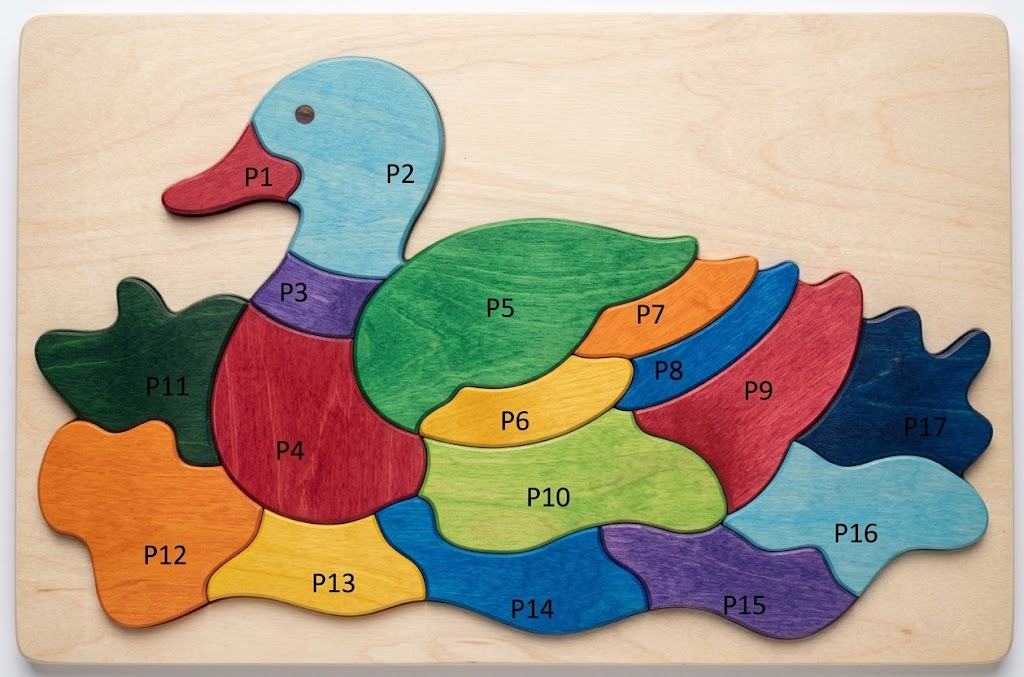

# Ejercicios de Implementación

4. Encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$ utilizando el algoritmo _hill climbing_.

## 4. Máximo de una función mediante Ascensión de Colinas

Se desea encontrar el máximo de:

$$
f(x)=\frac{\sin(x)}{x+0.1}
$$

en el intervalo:

$$
x\in[-10,-6]
$$

utilizando el algoritmo de **Ascensión de Colinas**.

Para representar el problema se definen los siguientes elementos:

- **Estado:** un valor posible de $x$ dentro del intervalo.
- **Función de evaluación:** el valor de $f(x)$.
- **Estado inicial:** $x=-10$.
- **Vecinos:** los puntos ubicados un paso a la izquierda y a la derecha del estado actual:

$$
x_{\text{izquierdo}}=x-\Delta x
$$

$$
x_{\text{derecho}}=x+\Delta x
$$

- **Movimiento:** se avanza hacia el vecino que tenga el mayor valor de $f(x)$.
- **Detención:** el algoritmo finaliza cuando ninguno de los vecinos mejora el valor del estado actual.

Se utiliza:

$$
\Delta x=0.01
$$

Como el paso es menor que $0.1$, permite obtener la precisión solicitada por el ejercicio.

Los valores que queden fuera del intervalo $[-10,-6]$ no se consideran vecinos válidos.

La función seno de Python trabaja en radianes, que es la unidad utilizada en este ejercicio.

In [2]:
import math


def funcion_objetivo(x):
    """Calcula el valor de la función que se desea maximizar."""
    return math.sin(x) / (x + 0.1)


def ascension_colinas(x_inicial, limite_inferior, limite_superior, paso):
    """Busca un máximo desplazándose hacia el mejor vecino."""
    x_actual = x_inicial
    iteraciones = 0

    while True:
        posibles_vecinos = (
            x_actual - paso,
            x_actual + paso
        )

        vecinos_validos = [
            x
            for x in posibles_vecinos
            if limite_inferior <= x <= limite_superior
        ]

        mejor_vecino = max(vecinos_validos, key=funcion_objetivo)

        if funcion_objetivo(mejor_vecino) <= funcion_objetivo(x_actual):
            return x_actual, funcion_objetivo(x_actual), iteraciones

        x_actual = mejor_vecino
        iteraciones += 1


LIMITE_INFERIOR = -10.0
LIMITE_SUPERIOR = -6.0
PASO = 0.01
X_INICIAL = LIMITE_INFERIOR

x_maximo, valor_maximo, cantidad_iteraciones = ascension_colinas(
    X_INICIAL,
    LIMITE_INFERIOR,
    LIMITE_SUPERIOR,
    PASO
)

print(f"Máximo aproximado en x = {x_maximo:.4f}")
print(f"Valor máximo f(x) = {valor_maximo:.6f}")
print(f"Cantidad de iteraciones = {cantidad_iteraciones}")

Máximo aproximado en x = -7.7200
Valor máximo f(x) = 0.130057
Cantidad de iteraciones = 228


### Resultado

El algoritmo comenzó en:

$$
x=-10
$$

y fue comparando el estado actual con sus dos posibles vecinos:

$$
x-\Delta x
\qquad\text{y}\qquad
x+\Delta x
$$

En cada iteración avanzó hacia el vecino con mayor valor de la función. El proceso se detuvo cuando ninguno de los dos vecinos produjo una mejora.

El máximo aproximado obtenido fue:

$$
x_{\max}\approx-7.72
$$

con un valor de:

$$
f(x_{\max})\approx0.130057
$$

El paso utilizado fue:

$$
\Delta x=0.01<0.1
$$

por lo que se cumple la precisión solicitada. El valor exacto del máximo se encuentra aproximadamente en $x=-7.7236$, de modo que el error de la aproximación obtenida es:

$$
|-7.72-(-7.7236)|\approx0.0036<0.1
$$

En este caso el algoritmo encuentra el máximo de la función dentro del intervalo. Sin embargo, como se estudió en la teoría, la Ascensión de Colinas no garantiza encontrar el máximo global en cualquier problema, ya que puede detenerse en un máximo local.

Verificacion por geogebra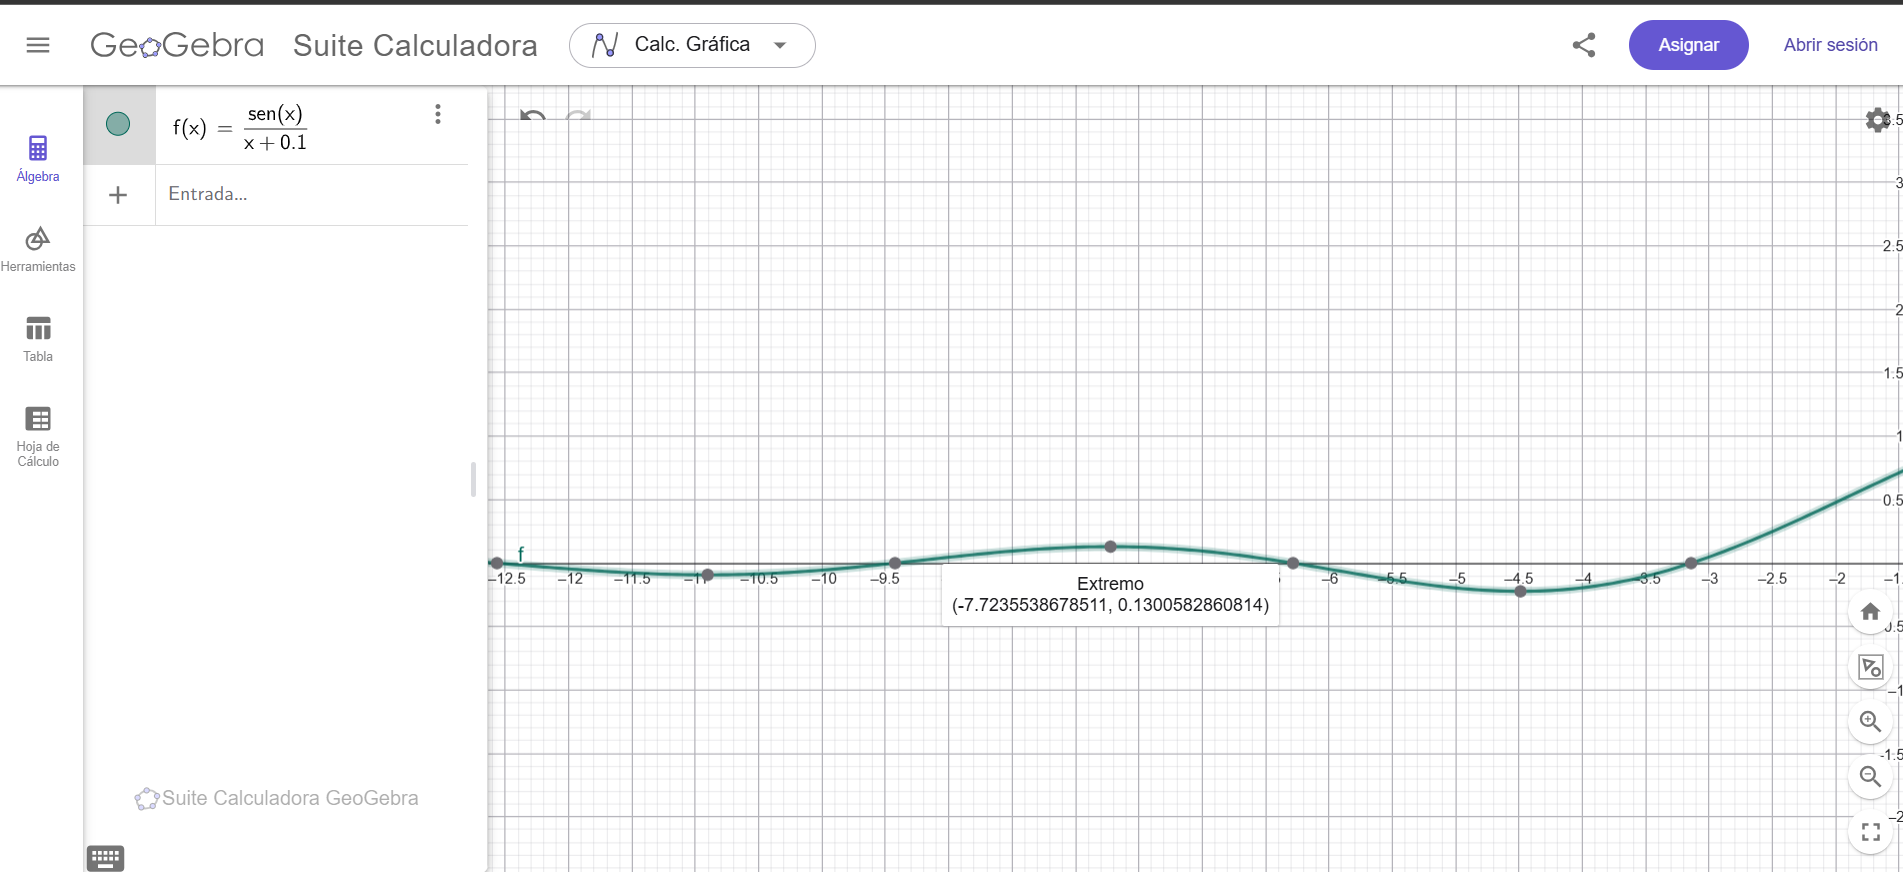

5. Diseñe e implemente un algoritmo de Recocido Simulado para que juegue contra usted al Ta-te-ti. Varíe los valores de temperatura inicial entre partidas, ¿qué diferencia observa cuando la temperatura es más alta con respecto a cuando la temperatura es más baja?

## 5. Ta-te-ti con Recocido Simulado e interfaz gráfica

El juego se implementa en una ventana independiente utilizando `pygame`.

- El jugador utiliza la ficha `X`.
- La inteligencia artificial utiliza la ficha `O`.
- El jugador comienza la partida.
- Las jugadas se realizan haciendo clic con el botón izquierdo del mouse.
- Las casillas ocupadas no pueden volver a seleccionarse.
- La tecla `R` reinicia la partida.
- La tecla `1` inicia una partida con temperatura baja.
- La tecla `2` inicia una partida con temperatura alta.
- La tecla `ESC` cierra la ventana.

### Representación utilizada por el algoritmo

En cada turno de la inteligencia artificial, un estado representa una posible casilla en la que podría colocar su ficha.

El estado inicial se elige aleatoriamente entre las casillas vacías.

Los vecinos del estado actual son todas las demás casillas vacías. No se refiere únicamente a las casillas que se encuentran juntas físicamente en el tablero, sino a cualquier jugada alternativa disponible.

### Prioridades de la inteligencia artificial

Antes de aplicar Recocido Simulado se comprueban dos situaciones obligatorias:

1. Si la inteligencia artificial puede ganar, selecciona la casilla ganadora.
2. Si el jugador puede ganar en su próximo turno, selecciona la casilla necesaria para bloquearlo.
3. Si no ocurre ninguna de las situaciones anteriores, se utiliza Recocido Simulado.

### Evaluación de las casillas

Cada posición tiene un valor base:

| Posición | Valor |
|---|---:|
| Centro | 3 |
| Esquina | 2 |
| Borde | 1 |

Además:

- Formar dos fichas de la IA y una casilla vacía suma 10 puntos.
- Formar una ficha de la IA y dos casillas vacías suma 2 puntos.
- Bloquear una línea con fichas de ambos jugadores suma 1 punto.

En un tablero vacío, las evaluaciones iniciales serían:

| Posición | Evaluación |
|---|---:|
| Centro | 11 |
| Esquina | 8 |
| Borde | 5 |

Por lo tanto, aunque la solución inicial sea aleatoria, el centro tiene una evaluación mayor. Con temperatura baja, el algoritmo normalmente termina seleccionándolo. Con temperatura alta puede aceptar una alternativa peor y elegir otra posición.

### Aceptación de un vecino

Se calcula:

$$
\Delta=E(s_{\text{vecino}})-E(s_{\text{actual}})
$$

- Si $\Delta>0$, el vecino es mejor y siempre se acepta.
- Si $\Delta=0$, ambos tienen el mismo valor y el vecino también se acepta.
- Si $\Delta<0$, el vecino es peor y se acepta con probabilidad:

$$
P(\text{aceptar})=e^{\frac{\Delta}{T}}
$$

### Parámetros utilizados

| Parámetro | Valor |
|---|---:|
| Temperatura inicial baja | 0.1 |
| Temperatura inicial alta | 20 |
| Temperatura mínima | 0.01 |
| Factor de enfriamiento | 0.90 |
| Máximo de iteraciones | 30 |

Después de cada iteración:

$$
T_{\text{nueva}}=0.90\cdot T_{\text{actual}}
$$

La interfaz muestra cuántas alternativas peores fueron aceptadas por el algoritmo. Esto permite comparar directamente el comportamiento con temperatura alta y baja.

In [3]:
%pip install pygame

Note: you may need to restart the kernel to use updated packages.


In [4]:
import math
import random  #para realizar elecciones aleatorias
import pygame

# ============================================================
# CONFIGURACIÓN DEL JUEGO
# ============================================================

JUGADOR = "X"
IA = "O"
VACIA = " "

# Filas, columnas y diagonales que producen una victoria.
LINEAS_GANADORAS = (
    (0, 1, 2),
    (3, 4, 5),
    (6, 7, 8),
    (0, 3, 6),
    (1, 4, 7),
    (2, 5, 8),
    (0, 4, 8),
    (2, 4, 6),
)

# Valores base: esquinas = 2, bordes = 1 y centro = 3.
VALOR_POSICION = (2, 1, 2, 1, 3, 1, 2, 1, 2)


# ============================================================
# PARÁMETROS DEL RECOCIDO SIMULADO
# ============================================================

TEMPERATURA_BAJA = 0.1
TEMPERATURA_ALTA = 20.0
TEMPERATURA_MINIMA = 0.01
FACTOR_ENFRIAMIENTO = 0.90
MAX_ITERACIONES = 30


# ============================================================
# FUNCIONES BÁSICAS
# ============================================================

def movimientos_disponibles(tablero):  #recibe el tablero
    movimientos = []

    for indice, celda in enumerate(tablero):   #enumerate obtiene el indice y el contenido de la casilla
        if celda == VACIA:
            movimientos.append(indice)

    return movimientos


def hay_ganador(tablero, ficha):

    for linea in LINEAS_GANADORAS:
        linea_completa = True

        for posicion in linea:
            if tablero[posicion] != ficha:
                linea_completa = False

        if linea_completa:
            return True

    return False


def buscar_jugada_inmediata(tablero, ficha):
    """
    Busca una casilla que permita completar una línea ganadora.

    Se utiliza para que la IA pueda ganar o para detectar
    una posible victoria del jugador y bloquearla.
    """

    for movimiento in movimientos_disponibles(tablero):
        tablero_prueba = tablero.copy()  #creamos una copia para probar el movimiento
        tablero_prueba[movimiento] = ficha

        if hay_ganador(tablero_prueba, ficha):
            return movimiento

    return None  #si no hay ninguna victoria posible no devuelve nada


# ============================================================
# FUNCIÓN DE EVALUACIÓN
# ============================================================

def evaluar_movimiento(tablero, movimiento):
    """Calcula la puntuación de una posible jugada de la IA."""
    tablero_prueba = tablero.copy()
    tablero_prueba[movimiento] = IA

    # Valor correspondiente a la ubicación elegida.
    puntuacion = VALOR_POSICION[movimiento]

    for linea in LINEAS_GANADORAS:
        valores = [
            tablero_prueba[posicion]
            for posicion in linea
        ]

        cantidad_ia = valores.count(IA)
        cantidad_vacias = valores.count(VACIA)

        # Se valoran las líneas que todavía puede completar la IA.
        if JUGADOR not in valores:
            if cantidad_ia == 2 and cantidad_vacias == 1:
                puntuacion += 10
            elif cantidad_ia == 1 and cantidad_vacias == 2:
                puntuacion += 2

        # Una línea con fichas de ambos jugadores está bloqueada.
        if JUGADOR in valores and IA in valores:
            puntuacion += 1

    return puntuacion


# ============================================================
# RECOCIDO SIMULADO
# ============================================================

def elegir_movimiento_ia(tablero, temperatura_inicial):
    """Selecciona la próxima jugada de la IA."""

    # Prioridad 1: realizar una jugada ganadora.
    movimiento_ganador = buscar_jugada_inmediata(tablero, IA)

    if movimiento_ganador is not None:
        detalle = "Jugada obligatoria: la IA puede ganar"
        return movimiento_ganador, detalle

    # Prioridad 2: bloquear una victoria del jugador.
    movimiento_bloqueo = buscar_jugada_inmediata(
        tablero,
        JUGADOR
    )

    if movimiento_bloqueo is not None:
        detalle = "Jugada obligatoria: la IA bloquea al jugador"
        return movimiento_bloqueo, detalle

    movimientos = movimientos_disponibles(tablero)

    # Si solamente queda una casilla, se selecciona directamente.
    if len(movimientos) == 1:
        return movimientos[0], "Solo quedaba una casilla"

    # Solución inicial aleatoria.
    movimiento_actual = random.choice(movimientos)
    valor_actual = evaluar_movimiento(
        tablero,
        movimiento_actual
    )

    temperatura = temperatura_inicial
    peores_aceptados = 0

    for _ in range(MAX_ITERACIONES):  #puede ejecutarse maximo 30 veces

        # Cualquier otra casilla vacía es una solución vecina.
        vecinos = [
            movimiento
            for movimiento in movimientos
            if movimiento != movimiento_actual
        ]

        movimiento_vecino = random.choice(vecinos)
        valor_vecino = evaluar_movimiento(
            tablero,
            movimiento_vecino
        )

        diferencia = valor_vecino - valor_actual

        # Una alternativa mejor o igual siempre se acepta.
        aceptar_vecino = diferencia >= 0

        # Una alternativa peor se acepta según la temperatura.
        if diferencia < 0:
            probabilidad = math.exp(
                diferencia / temperatura
            )
            aceptar_vecino = (
                random.random() < probabilidad
            )

        if aceptar_vecino:
            if diferencia < 0:
                peores_aceptados += 1

            movimiento_actual = movimiento_vecino
            valor_actual = valor_vecino

        # Enfriamiento.
        temperatura *= FACTOR_ENFRIAMIENTO

        if temperatura < TEMPERATURA_MINIMA:
            break

    detalle = (
        f"Recocido: puntuación {valor_actual} | "
        f"peores aceptados {peores_aceptados}"
    )

    return movimiento_actual, detalle

pygame 2.6.1 (SDL 2.28.4, Python 3.13.6)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [5]:
# ============================================================
# CONFIGURACIÓN DE LA VENTANA
# ============================================================

ANCHO = 600
ALTO_TABLERO = 600
ALTO_VENTANA = 720
TAM_CELDA = ALTO_TABLERO // 3
FPS = 60

# Colores RGB.
COLOR_FONDO = (248, 249, 252)
COLOR_CELDA = (255, 255, 255)
COLOR_SELECCION = (232, 240, 254)
COLOR_GRILLA = (50, 55, 65)
COLOR_X = (45, 105, 210)
COLOR_O = (235, 120, 45)
COLOR_TEXTO = (35, 40, 50)


def dibujar_interfaz(
    pantalla,
    tablero,
    mensaje,
    detalle,
    temperatura_inicial,
    partida_terminada
):
    """Dibuja el tablero, las fichas y los mensajes."""

    pantalla.fill(COLOR_FONDO)

    # --------------------------------------------------------
    # Dibujar el fondo de las nueve casillas
    # --------------------------------------------------------

    for fila in range(3):
        for columna in range(3):
            rectangulo = pygame.Rect(
                columna * TAM_CELDA,
                fila * TAM_CELDA,
                TAM_CELDA,
                TAM_CELDA
            )

            pygame.draw.rect(
                pantalla,
                COLOR_CELDA,
                rectangulo
            )

    # --------------------------------------------------------
    # Resaltar la casilla sobre la que está el mouse
    # --------------------------------------------------------

    mouse_x, mouse_y = pygame.mouse.get_pos()

    if not partida_terminada and mouse_y < ALTO_TABLERO:
        columna = mouse_x // TAM_CELDA
        fila = mouse_y // TAM_CELDA
        movimiento = fila * 3 + columna

        if tablero[movimiento] == VACIA:
            seleccion = pygame.Rect(
                columna * TAM_CELDA,
                fila * TAM_CELDA,
                TAM_CELDA,
                TAM_CELDA
            )

            pygame.draw.rect(
                pantalla,
                COLOR_SELECCION,
                seleccion
            )

    # --------------------------------------------------------
    # Dibujar la grilla
    # --------------------------------------------------------

    for posicion in (1, 2):
        coordenada = posicion * TAM_CELDA

        pygame.draw.line(
            pantalla,
            COLOR_GRILLA,
            (coordenada, 0),
            (coordenada, ALTO_TABLERO),
            6
        )

        pygame.draw.line(
            pantalla,
            COLOR_GRILLA,
            (0, coordenada),
            (ANCHO, coordenada),
            6
        )

    # --------------------------------------------------------
    # Dibujar las fichas X y O
    # --------------------------------------------------------

    margen = 45

    for indice, ficha in enumerate(tablero):
        fila = indice // 3
        columna = indice % 3

        x = columna * TAM_CELDA
        y = fila * TAM_CELDA

        if ficha == JUGADOR:
            # Primera línea de la X.
            pygame.draw.line(
                pantalla,
                COLOR_X,
                (x + margen, y + margen),
                (
                    x + TAM_CELDA - margen,
                    y + TAM_CELDA - margen
                ),
                14
            )

            # Segunda línea de la X.
            pygame.draw.line(
                pantalla,
                COLOR_X,
                (
                    x + TAM_CELDA - margen,
                    y + margen
                ),
                (
                    x + margen,
                    y + TAM_CELDA - margen
                ),
                14
            )

        elif ficha == IA:
            centro = (
                x + TAM_CELDA // 2,
                y + TAM_CELDA // 2
            )

            pygame.draw.circle(
                pantalla,
                COLOR_O,
                centro,
                TAM_CELDA // 3,
                14
            )

    # --------------------------------------------------------
    # Mostrar información debajo del tablero
    # --------------------------------------------------------

    fuente_estado = pygame.font.SysFont(
        "Arial",
        27,
        bold=True
    )
    fuente_detalle = pygame.font.SysFont("Arial", 20)
    fuente_ayuda = pygame.font.SysFont("Arial", 18)

    texto_estado = fuente_estado.render(
        mensaje,
        True,
        COLOR_TEXTO
    )

    texto_detalle = fuente_detalle.render(
        detalle,
        True,
        COLOR_TEXTO
    )

    ayuda = (
        f"Temperatura: {temperatura_inicial:g} | "
        "1: baja | 2: alta | R: reiniciar | ESC: salir"
    )

    texto_ayuda = fuente_ayuda.render(
        ayuda,
        True,
        COLOR_TEXTO
    )

    pantalla.blit(texto_estado, (20, 610))
    pantalla.blit(texto_detalle, (20, 650))
    pantalla.blit(texto_ayuda, (20, 690))


def jugar_tateti(
    temperatura_inicial=TEMPERATURA_BAJA
):
    """Abre la ventana y ejecuta una partida interactiva."""

    if temperatura_inicial <= 0:
        raise ValueError(
            "La temperatura debe ser mayor que cero."
        )

    pygame.init()

    pantalla = pygame.display.set_mode(
        (ANCHO, ALTO_VENTANA)
    )

    pygame.display.set_caption(
        "Ta-te-ti con Recocido Simulado"
    )

    reloj = pygame.time.Clock()

    # Estado inicial.
    tablero = [VACIA] * 9
    mensaje = "Tu turno: elegí una casilla"
    detalle = "X = jugador | O = inteligencia artificial"
    partida_terminada = False
    ejecutando = True

    # ========================================================
    # BUCLE PRINCIPAL
    # ========================================================

    while ejecutando:

        for evento in pygame.event.get():

            # Cerrar la ventana.
            if evento.type == pygame.QUIT:
                ejecutando = False

            # ------------------------------------------------
            # Controles del teclado
            # ------------------------------------------------

            elif evento.type == pygame.KEYDOWN:

                if evento.key == pygame.K_ESCAPE:
                    ejecutando = False

                elif evento.key in (
                    pygame.K_r,
                    pygame.K_1,
                    pygame.K_2
                ):
                    # Cambiar la temperatura cuando corresponda.
                    if evento.key == pygame.K_1:
                        temperatura_inicial = TEMPERATURA_BAJA

                    elif evento.key == pygame.K_2:
                        temperatura_inicial = TEMPERATURA_ALTA

                    # Reiniciar el tablero.
                    tablero = [VACIA] * 9
                    mensaje = "Tu turno: elegí una casilla"
                    detalle = "Partida nueva"
                    partida_terminada = False

            # ------------------------------------------------
            # Selección de una casilla con el mouse
            # ------------------------------------------------

            elif (
                evento.type == pygame.MOUSEBUTTONDOWN
                and evento.button == 1
                and not partida_terminada
            ):
                mouse_x, mouse_y = evento.pos

                # Los clics debajo del tablero se ignoran.
                if mouse_y >= ALTO_TABLERO:
                    continue

                # Convertir píxeles en fila y columna.
                columna = mouse_x // TAM_CELDA
                fila = mouse_y // TAM_CELDA

                movimiento_jugador = fila * 3 + columna

                # No permitir seleccionar una casilla ocupada.
                if tablero[movimiento_jugador] != VACIA:
                    detalle = "Esa casilla ya está ocupada"
                    continue

                tablero[movimiento_jugador] = JUGADOR

                # Comprobar el resultado del jugador.
                if hay_ganador(tablero, JUGADOR):
                    mensaje = "Ganaste la partida"
                    detalle = "Presioná R para volver a jugar"
                    partida_terminada = True

                elif not movimientos_disponibles(tablero):
                    mensaje = "La partida terminó en empate"
                    detalle = "Presioná R para volver a jugar"
                    partida_terminada = True

                else:
                    # Mostrar primero la jugada del jugador.
                    mensaje = "La IA está pensando..."
                    detalle = ""

                    dibujar_interfaz(
                        pantalla,
                        tablero,
                        mensaje,
                        detalle,
                        temperatura_inicial,
                        partida_terminada
                    )

                    pygame.display.flip()
                    pygame.time.delay(250)

                    # Obtener y colocar la jugada de la IA.
                    movimiento_ia, detalle = elegir_movimiento_ia(
                        tablero,
                        temperatura_inicial
                    )

                    tablero[movimiento_ia] = IA

                    # Comprobar el resultado de la IA.
                    if hay_ganador(tablero, IA):
                        mensaje = "Ganó la inteligencia artificial"
                        partida_terminada = True

                    elif not movimientos_disponibles(tablero):
                        mensaje = "La partida terminó en empate"
                        partida_terminada = True

                    else:
                        mensaje = "Tu turno: elegí una casilla"

        # Dibujar el estado actual.
        dibujar_interfaz(
            pantalla,
            tablero,
            mensaje,
            detalle,
            temperatura_inicial,
            partida_terminada
        )

        pygame.display.flip()
        reloj.tick(FPS)

    # Cierra solamente la ventana de Pygame.
    pygame.quit()

### Ejecución de la partida

Al ejecutar la siguiente celda se abrirá una ventana independiente.

Los controles son:

- **Clic izquierdo:** colocar una `X` en una casilla vacía.
- **Tecla 1:** comenzar otra partida con temperatura baja, $T_0=0.1$.
- **Tecla 2:** comenzar otra partida con temperatura alta, $T_0=20$.
- **Tecla R:** reiniciar manteniendo la temperatura actual.
- **Tecla ESC:** cerrar la ventana.

Las casillas vacías se muestran de color blanco. Cuando el mouse se encuentra sobre una casilla disponible, esta se resalta de color celeste claro.

Después de cada movimiento de la inteligencia artificial se muestra:

- La puntuación de la jugada seleccionada.
- La cantidad de alternativas peores aceptadas.
- Si la jugada fue una victoria o un bloqueo obligatorio.

In [6]:
jugar_tateti(temperatura_inicial=TEMPERATURA_BAJA)

##Ejemplos de Ejecuciones:  

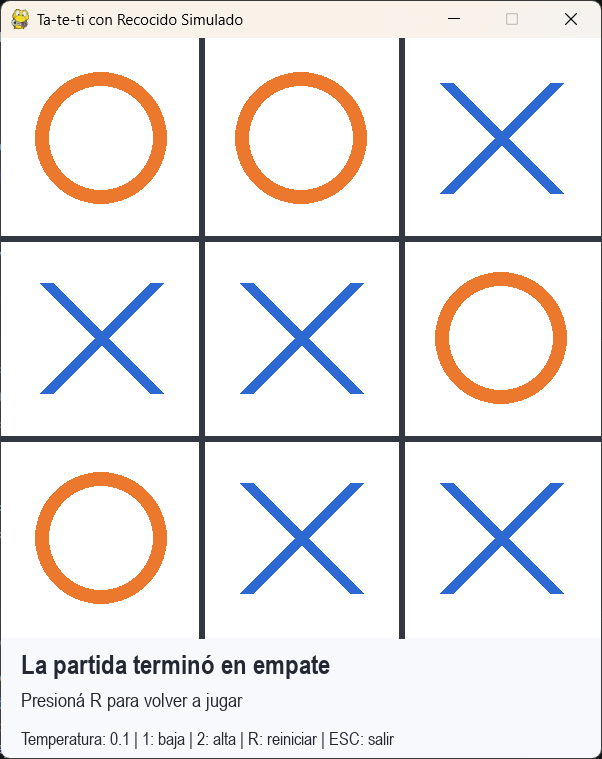
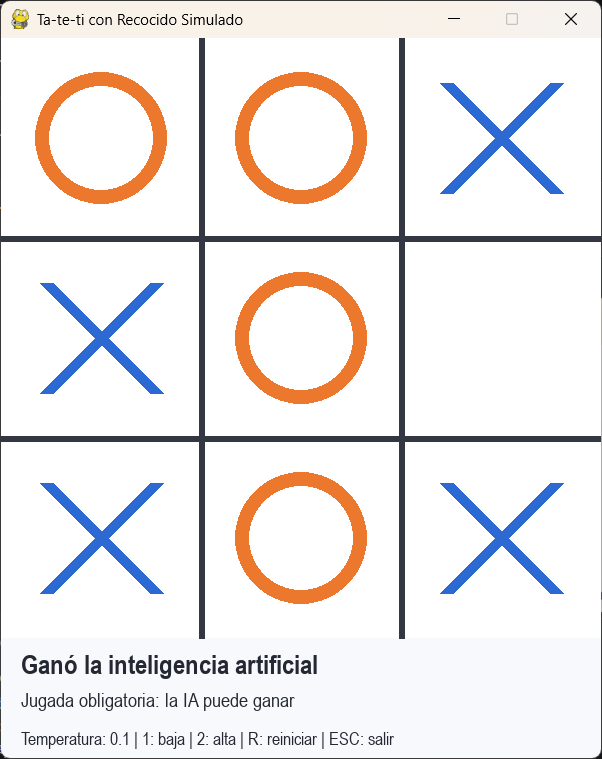
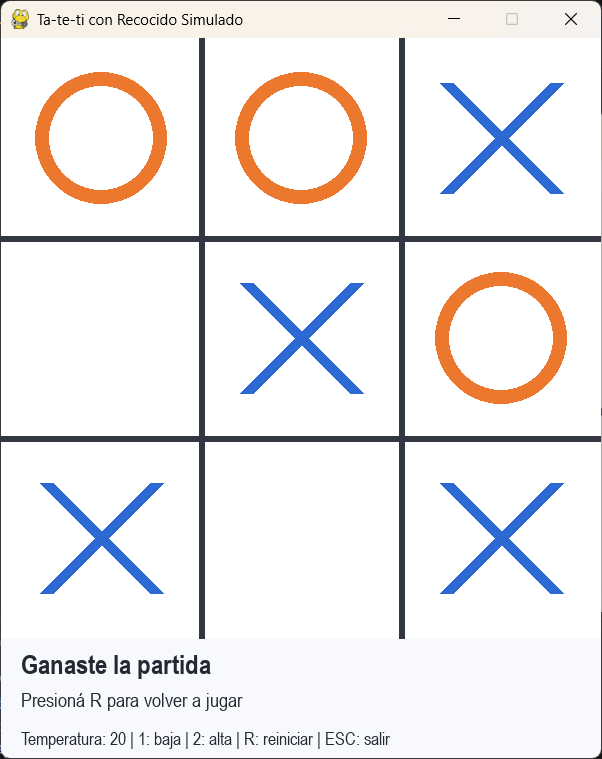
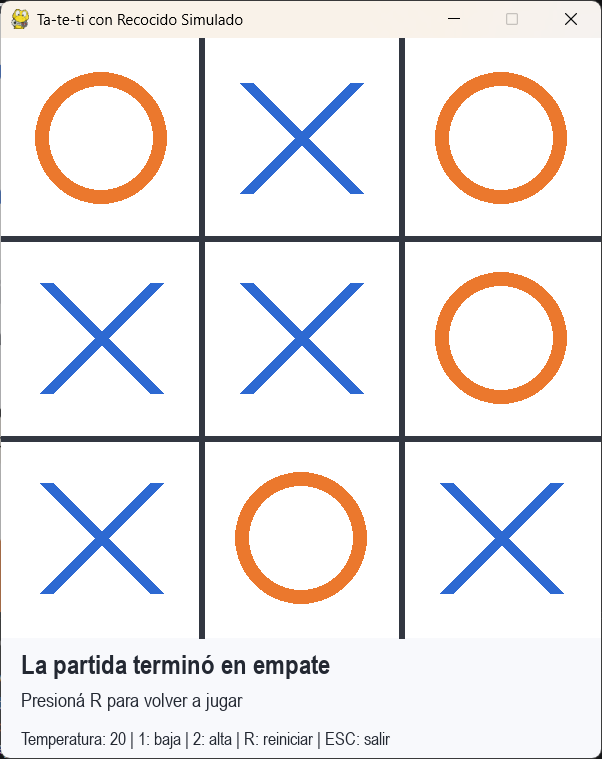

### Resultados observados

Con temperatura inicial baja:

$$
T_0=0.1
$$

la inteligencia artificial acepta muy pocas alternativas con menor puntuación. Por esta razón, presenta un comportamiento más selectivo y suele elegir el centro, las esquinas o las jugadas que formen mejores líneas.

Con temperatura inicial alta:

$$
T_0=20
$$

se aceptan más alternativas con menor puntuación. El comportamiento resulta más exploratorio y menos predecible, por lo que la inteligencia artificial puede seleccionar una casilla de menor evaluación aunque exista otra mejor.

La cantidad mostrada como `peores aceptados` normalmente es mayor cuando se utiliza temperatura alta.

Las jugadas inmediatas de victoria y bloqueo se verifican antes de aplicar Recocido Simulado. Por lo tanto, estas decisiones no dependen de la temperatura.

El algoritmo no garantiza jugar de manera perfecta, ya que no analiza el árbol completo de posibles partidas. Su objetivo en este ejercicio es mostrar cómo la temperatura modifica la aceptación de soluciones de menor calidad durante la búsqueda.


6. Diseñe e implemente un algoritmo genético para cargar una grúa con $n=10\;cajas$ que puede soportar un peso máximo $C=1000\;kg$. Cada caja *j* tiene asociado un precio $p_j$ y un peso $w_j$ como se indica en la tabla de abajo, de manera que el algoritmo debe ser capaz de maximizar el precio sin superar el límite de carga.

<table><tr><td>Elemento ($j$)</td><td>1</td><td>2</td><td>3</td><td>4</td><td>5</td><td>6</td><td>7</td><td>8</td><td>9</td><td>10</td></tr>

<tr><td>Precio ($p_j$)</td><td>100</td><td>50</td><td>115</td><td>25</td><td>200</td><td>30</td><td>40</td><td>100</td><td>100</td><td>100</td></tr>

<tr><td>Peso ($w_j$)</td><td>300</td><td>200</td><td>450</td><td>145</td><td>664</td><td>90</td><td>150</td><td>355</td><td>401</td><td>395</td></tr></table><br>

        6.1 En primer lugar, es necesario representar qué cajas estarán cargadas en la grúa y cuáles no. Esta representación corresponde a un Individuo con el que trabajará el algoritmo.

        6.2 A continuación, genere una Población que contenga un número $N$ de individuos (se recomienda elegir un número par). Es necesario crear un control que verifique que ninguno de los individuos supere el peso límite.

        6.3 Cree ahora una función que permita evaluar la Idoneidad de cada individuo y seleccione $N/2$ parejas usando el método de la ruleta.

        6.4 Por último, Cruce las parejas elegidas, aplique un mecanismo de Mutación y verifique que los individuos de la nueva población no superen el límite de peso.

        6.5 Realice este proceso iterativamente hasta que se cumpla el mecanismo de detención de su elección y muestre el mejor individuo obtenido junto con el peso y el precio que alcanza.

In [7]:
import random

# ==========================================
# DATOS DEL PROBLEMA
# ==========================================
PRECIOS = [100, 50, 115, 25, 200, 30, 40, 100, 100, 100]
PESOS   = [300, 200, 450, 145, 664, 90, 150, 355, 401, 395]
PESO_MAXIMO = 1000  # Modificar según el límite requerido
N_ELEMENTOS = len(PRECIOS)

# HIPERPARÁMETROS DEL ALGORITMO GENÉTICO
TAM_POBLACION = 30     # N (par)
PROB_CRUCE = 0.85
PROB_MUTACION = 0.05
NUM_GENERACIONES = 60

# ==========================================
# 6.1 Y 6.2 REPRESENTACIÓN, CONTROL Y POBLACIÓN
# ==========================================
def calcular_peso_y_precio(individuo):
    peso = sum(gen * w for gen, w in zip(individuo, PESOS))
    precio = sum(gen * p for gen, p in zip(individuo, PRECIOS))
    return peso, precio

def reparar_individuo(individuo):
    """Garantiza que el individuo no exceda el peso máximo."""
    ind = individuo.copy()
    peso, _ = calcular_peso_y_precio(ind)
    
    # Si excede el peso, apaga cajas aleatoriamente hasta ser factible
    cajas_activas = [i for i, gen in enumerate(ind) if gen == 1]
    random.shuffle(cajas_activas)
    
    while peso > PESO_MAXIMO and cajas_activas:
        idx = cajas_activas.pop()
        ind[idx] = 0
        peso, _ = calcular_peso_y_precio(ind)
        
    return ind

def crear_individuo():
    ind = [random.choice([0, 1]) for _ in range(N_ELEMENTOS)]
    return reparar_individuo(ind)

def generar_poblacion(n):
    return [crear_individuo() for _ in range(n)]

# ==========================================
# 6.3 EVALUACIÓN E IDONEIDAD (RULETA)
# ==========================================
def evaluar_fitness(individuo):
    peso, precio = calcular_peso_y_precio(individuo)
    return precio if peso <= PESO_MAXIMO else 0

def seleccion_ruleta(poblacion, num_padres):
    fitness_vals = [evaluar_fitness(ind) for ind in poblacion]
    suma_fitness = sum(fitness_vals)
    
    # En caso de que todos tengan fitness 0
    if suma_fitness == 0:
        return random.choices(poblacion, k=num_padres)
    
    probabilidades = [f / suma_fitness for f in fitness_vals]
    return random.choices(poblacion, weights=probabilidades, k=num_padres)

# ==========================================
# 6.4 CRUCE, MUTACIÓN Y VERIFICACIÓN
# ==========================================
def cruzar(p1, p2):
    if random.random() < PROB_CRUCE:
        punto = random.randint(1, N_ELEMENTOS - 1)
        hijo1 = p1[:punto] + p2[punto:]
        hijo2 = p2[:punto] + p1[punto:]
    else:
        hijo1, hijo2 = p1.copy(), p2.copy()
    return hijo1, hijo2

def mutar(individuo):
    for i in range(len(individuo)):
        if random.random() < PROB_MUTACION:
            individuo[i] = 1 - individuo[i]  # Bit-flip
    return individuo

# ==========================================
# 6.5 BUCLE PRINCIPAL (DETENCIÓN Y RESULTADOS)
# ==========================================
def ejecutar_algoritmo():
    poblacion = generar_poblacion(TAM_POBLACION)
    mejor_global = None
    mejor_fitness = -1

    for gen in range(NUM_GENERACIONES):
        # Evaluar mejor de la generación actual
        for ind in poblacion:
            fit = evaluar_fitness(ind)
            if fit > mejor_fitness:
                mejor_fitness = fit
                mejor_global = ind.copy()

        # Selección de N/2 parejas (N padres en total)
        padres = seleccion_ruleta(poblacion, TAM_POBLACION)
        nueva_poblacion = []

        # Cruce y Mutación por pares
        for i in range(0, TAM_POBLACION, 2):
            h1, h2 = cruzar(padres[i], padres[i+1])
            
            # Mutar y verificar factibilidad
            h1 = reparar_individuo(mutar(h1))
            h2 = reparar_individuo(mutar(h2))
            
            nueva_poblacion.extend([h1, h2])

        poblacion = nueva_poblacion

    # Resultados finales
    peso_final, precio_final = calcular_peso_y_precio(mejor_global)
    cajas_seleccionadas = [i + 1 for i, gen in enumerate(mejor_global) if gen == 1]

    print("=== MEJOR SOLUCIÓN ENCONTRADA ===")
    print(f"Cromosoma binario: {mejor_global}")
    print(f"Cajas cargadas (j): {cajas_seleccionadas}")
    print(f"Peso total: {peso_final} / {PESO_MAXIMO}")
    print(f"Precio total: {precio_final}")

if __name__ == "__main__":
    ejecutar_algoritmo()

=== MEJOR SOLUCIÓN ENCONTRADA ===
Cromosoma binario: [1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
Cajas cargadas (j): [1, 5]
Peso total: 964 / 1000
Precio total: 300


# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)